# Aula 03 — Agrupamentos multi-index

Mesma base das aulas anteriores (planilha SEEG, aba `GEE Estados`, em `../01_conhecendo_os_dados/dados/`).

As células de preparação refazem o caminho das Aulas 01 e 02: filtrar `Emissão`, descartar a coluna do tipo e derreter (`melt`) para o formato longo — é sobre `emissoes_por_ano` que os agrupamentos com múltiplas chaves vão operar.

**Padrão bruto → tratado:** `emissoes_brutas` nunca é alterado; as células de tratamento podem ser reexecutadas à vontade.

In [64]:
import pandas as pd

In [65]:
# Célula LENTA — roda uma vez só. O bruto nunca é alterado depois daqui.
emissoes_brutas = pd.read_excel(
    '../01_conhecendo_os_dados/dados/1-SEEG10_GERAL-BR_UF_2022.10.27-FINAL-SITE.xlsx',
    sheet_name='GEE Estados'
)
emissoes_brutas.shape

C:\Users\ti_rickelme\AppData\Roaming\Python\Python314\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


(103312, 63)

In [66]:
# Tratamento da Aula 01: só linhas de Emissão
emissoes_gases = emissoes_brutas[emissoes_brutas['Emissão / Remoção / Bunker'] == 'Emissão'].copy()
emissoes_gases = emissoes_gases.drop(columns='Emissão / Remoção / Bunker')

# Validação: (94748, 62)
emissoes_gases.shape

(94748, 62)

In [67]:
# Preparação da Aula 02: wide → long com melt
colunas_info = list(emissoes_gases.loc[:, 'Nível 1 - Setor':'Produto'].columns)
colunas_emissao = list(emissoes_gases.loc[:, 1970:2021].columns)

emissoes_por_ano = emissoes_gases.melt(
    id_vars=colunas_info,
    value_vars=colunas_emissao,
    var_name='Ano',
    value_name='Emissão'
)

# Validação: (4926896, 12) — 94.748 linhas × 52 anos
emissoes_por_ano.shape

(4926896, 12)

In [68]:
# Colchete DUPLO [['Emissão']] → DataFrame (igual ao notebook do curso)
# Com colchete simples ['Emissão'] viraria Series — e Series não tem insert()
gas_por_setor = emissoes_por_ano.groupby(['Gás', 'Nível 1 - Setor'])[['Emissão']].sum()
gas_por_setor

Emissão
Gás      Nível 1 - Setor                                 
C2F6 (t) Processos Industriais               5.765018e+02
CF4 (t)  Processos Industriais               7.135481e+03
CH4 (t)  Agropecuária                        5.928481e+08
         Energia                             3.429034e+07
         Mudança de Uso da Terra e Floresta  8.662166e+07
...                                                   ...
N2O (t)  Resíduos                            2.764127e+05
NOx (t)  Agropecuária                        2.602719e+06
         Energia                             9.361215e+07
         Processos Industriais               3.546360e+06
SF6 (t)  Processos Industriais               4.705800e+02

[72 rows x 1 columns]

In [69]:
gas_por_setor.xs('CO2 (t)', level = 0)

,Emissão
Nível 1 - Setor,
Agropecuária,5.411750e+08
Energia,1.261352e+10
Mudança de Uso da Terra e Floresta,3.733930e+10
Processos Industriais,2.729603e+09
Resíduos,2.276264e+07


In [70]:
gas_por_setor.xs(('CO2 (t)', 'Mudança de Uso da Terra e Floresta'), level = [0,1])

,,Emissão
Gás,Nível 1 - Setor,
CO2 (t),Mudança de Uso da Terra e Floresta,3.733930e+10


In [71]:
gas_por_setor.xs('CO2 (t)', level = 0).max()

Emissão    3.733930e+10
dtype: float64

In [72]:
gas_por_setor.xs('CO2 (t)', level = 0).idxmax()

Emissão    Mudança de Uso da Terra e Floresta
dtype: object

In [73]:
gas_por_setor.groupby(level = 0).idxmax()

,Emissão
Gás,
C2F6 (t),"(C2F6 (t), Processos Industriais)"
CF4 (t),"(CF4 (t), Processos Industriais)"
CH4 (t),"(CH4 (t), Agropecuária)"
CO (t),"(CO (t), Energia)"
CO2 (t),"(CO2 (t), Mudança de Uso da Terra e Floresta)"
CO2e (t) GTP-AR2,"(CO2e (t) GTP-AR2, Mudança de Uso da Terra e F..."
CO2e (t) GTP-AR4,"(CO2e (t) GTP-AR4, Mudança de Uso da Terra e F..."
CO2e (t) GTP-AR5,"(CO2e (t) GTP-AR5, Mudança de Uso da Terra e F..."
CO2e (t) GTP-AR6,"(CO2e (t) GTP-AR6, Mudança de Uso da Terra e F..."


In [74]:
gas_por_setor.groupby(level = 0).max()

,Emissão
Gás,
C2F6 (t),5.765018e+02
CF4 (t),7.135481e+03
CH4 (t),5.928481e+08
CO (t),3.959769e+08
CO2 (t),3.733930e+10
CO2e (t) GTP-AR2,3.850044e+10
CO2e (t) GTP-AR4,3.850044e+10
CO2e (t) GTP-AR5,3.831675e+10
CO2e (t) GTP-AR6,3.843359e+10


In [75]:
valores_max = gas_por_setor.groupby(level = 0).max().values

In [76]:
# idxmax em DataFrame devolve DataFrame → insert() funciona (era o que faltava na versão Series)
tabela_sumarizada = gas_por_setor.groupby(level=0).idxmax()
tabela_sumarizada.insert(1, 'Quantidade de emissão', valores_max)

# A coluna Emissão vem com a tupla inteira ('CO2 (t)', 'Mudança...'); .str[1] extrai só o setor
tabela_sumarizada['Emissão'] = tabela_sumarizada['Emissão'].str[1]

tabela_sumarizada

,Emissão,Quantidade de emissão
Gás,,
C2F6 (t),Processos Industriais,5.765018e+02
CF4 (t),Processos Industriais,7.135481e+03
CH4 (t),Agropecuária,5.928481e+08
CO (t),Energia,3.959769e+08
CO2 (t),Mudança de Uso da Terra e Floresta,3.733930e+10
CO2e (t) GTP-AR2,Mudança de Uso da Terra e Floresta,3.850044e+10
CO2e (t) GTP-AR4,Mudança de Uso da Terra e Floresta,3.850044e+10
CO2e (t) GTP-AR5,Mudança de Uso da Terra e Floresta,3.831675e+10
CO2e (t) GTP-AR6,Mudança de Uso da Terra e Floresta,3.843359e+10


In [77]:
gas_por_setor.swaplevel(0, 1).groupby(level=0).idxmax()

,Emissão
Nível 1 - Setor,
Agropecuária,"(Agropecuária, CO2e (t) GWP-AR5)"
Energia,"(Energia, CO2e (t) GWP-AR6)"
Mudança de Uso da Terra e Floresta,"(Mudança de Uso da Terra e Floresta, CO2e (t) ..."
Processos Industriais,"(Processos Industriais, CO2e (t) GWP-AR6)"
Resíduos,"(Resíduos , CO2e (t) GWP-AR5)"


In [78]:
emissoes_por_ano

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Gás,Estado,Atividade Econômica,Produto,Ano,Emissão
0,Processos Industriais,Indústria Química,Produção de ABS,NaN,NaN,NaN,COVNM (t),SP,OUTRA_IND,NaN,1970,0.0
1,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,N2O (t),SP,OUTRA_IND,NaN,1970,6210.0
2,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,CO (t),SP,OUTRA_IND,NaN,1970,368.0
3,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,NOx (t),SP,OUTRA_IND,NaN,1970,115.0
4,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,CO2e (t) GWP-AR2,SP,OUTRA_IND,NaN,1970,1925100.0
...,...,...,...,...,...,...,...,...,...,...,...,...
4926891,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,CO2e (t) GWP-AR5,MS,AGROPEC,NaN,2021,1004191.0
4926892,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,CO2e (t) GWP-AR6,MT,AGROPEC,NaN,2021,443120.0
4926893,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,CO2e (t) GWP-AR6,MS,AGROPEC,NaN,2021,1009968.0
4926894,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,N2O (t),MT,AGROPEC,NaN,2021,479.0


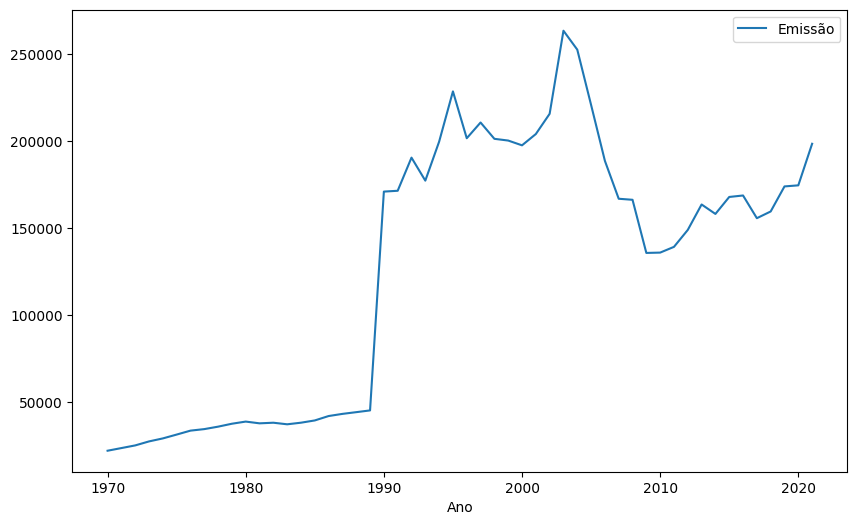

In [79]:
emissoes_por_ano.groupby('Ano')[['Emissão']].mean().plot(figsize = (10, 6));

In [80]:
emissoes_por_ano.groupby('Ano')[['Emissão']].mean().idxmax()

Emissão    2003
dtype: int64

In [81]:
emissoes_por_ano.groupby(['Ano', 'Gás'])[['Emissão']].mean()

Emissão
Ano  Gás                     
1970 C2F6 (t)        0.232610
     CF4 (t)         3.557421
     CH4 (t)      1471.024024
     CO (t)       2155.556658
     CO2 (t)     19244.913199
...                       ...
2021 HFC-23 (t)      0.000000
     HFC-32 (t)    261.100000
     N2O (t)       119.295311
     NOx (t)       679.395431
     SF6 (t)         5.240000

[1196 rows x 1 columns]

In [82]:
media_emissao_anual = emissoes_por_ano.groupby(['Ano', 'Gás'])[['Emissão']].mean().reset_index()
media_emissao_anual

,Ano,Gás,Emissão
0,1970,C2F6 (t),0.232610
1,1970,CF4 (t),3.557421
2,1970,CH4 (t),1471.024024
3,1970,CO (t),2155.556658
4,1970,CO2 (t),19244.913199
...,...,...,...
1191,2021,HFC-23 (t),0.000000
1192,2021,HFC-32 (t),261.100000
1193,2021,N2O (t),119.295311
1194,2021,NOx (t),679.395431


In [83]:
# Nome NOVO: o pivot muda o formato (long → wide) e consome a coluna 'Emissão'.
# Se sobrescrevesse media_emissao_anual, a 2ª execução daria KeyError: 'Emissão'.
media_emissao_pivotada = media_emissao_anual.pivot_table(index='Ano', columns='Gás', values='Emissão')
media_emissao_pivotada

Gás,C2F6 (t),CF4 (t),CH4 (t),CO (t),CO2 (t),CO2e (t) GTP-AR2,CO2e (t) GTP-AR4,CO2e (t) GTP-AR5,CO2e (t) GTP-AR6,CO2e (t) GWP-AR2,...,COVNM (t),HFC-125 (t),HFC-134a (t),HFC-143a (t),HFC-152a (t),HFC-23 (t),HFC-32 (t),N2O (t),NOx (t),SF6 (t)
Ano,,,,,,,,,,,,,,,,,,,,,
1970,0.232610,3.557421,1471.024024,2155.556658,19244.913199,20821.379814,20821.379814,19162.726020,19775.283385,35396.183865,...,742.074863,0.000000,0.000000,0.000000,0.0,0.00,0.00,31.632709,154.072797,0.000
1971,0.334611,5.117360,1525.506914,2259.625805,21598.587743,22466.288595,22466.288595,20748.481445,21386.175802,37570.982886,...,730.119047,0.000000,0.000000,0.000000,0.0,0.00,0.00,32.609237,170.550178,0.000
1972,0.404684,6.189025,1584.719568,2418.944795,23664.445521,24100.305265,24100.305265,22303.224240,22966.797327,39800.768350,...,774.278817,0.000000,0.000000,0.000000,0.0,0.00,0.00,34.311864,188.856161,0.000
1973,0.463147,7.083136,1642.612439,2596.053853,27726.668829,26683.827206,26683.827206,24827.077028,25516.409611,42947.755490,...,796.866394,0.000000,0.000000,0.000000,0.0,0.00,0.00,35.278689,217.320480,0.000
1974,0.471026,7.203619,1704.614365,2681.450599,30155.918952,28539.318732,28539.318732,26600.481407,27321.124852,45431.240064,...,1024.694923,0.000000,0.000000,0.000000,0.0,0.00,0.00,37.098183,247.521415,0.000
1975,0.502952,7.691893,1854.360821,2730.894830,32292.965771,30593.767465,30593.767465,28507.669059,29285.642221,48944.729581,...,1065.682750,0.000000,0.000000,0.000000,0.0,0.00,0.00,39.451008,262.716346,0.000
1976,0.577172,8.826970,1932.641716,2702.494362,35640.344723,33066.878007,33066.878007,30879.481709,31693.226162,52203.028009,...,1091.778909,0.000000,0.000000,0.000000,0.0,0.00,0.00,41.583225,287.013048,0.000
1977,0.692855,10.596169,1931.897645,2675.992077,37313.909077,34182.312333,34182.312333,31967.243034,32784.131397,53333.605735,...,1147.712448,0.000000,0.000000,0.000000,0.0,0.00,0.00,42.571086,292.405821,0.000
1978,0.749660,11.464915,1921.281930,2755.891877,40669.820049,35969.633601,35969.633601,33762.778999,34580.720998,55015.291182,...,1289.853564,0.000000,0.000000,0.000000,0.0,0.00,0.00,42.426649,322.982906,0.000


## Desafio: emissão por setor econômico

Média de emissão de cada setor (`Nível 1 - Setor`) ao longo dos anos — usando **apenas `pivot_table`, sem `groupby`**.

A sacada: o `pivot_table` tem o parâmetro `aggfunc`, que agrega sozinho as linhas que caem na mesma combinação Ano × Setor. Ele é um groupby disfarçado — o que fizemos antes em três passos (`groupby` → `reset_index` → `pivot_table`) sai em um.

In [84]:
# Direto no formato longo, sem groupby: aggfunc='mean' agrega as linhas de cada Ano × Setor
# (é também o padrão do pivot_table — explícito aqui porque é o ponto do desafio)
media_emissao_setor = emissoes_por_ano.pivot_table(
    index='Ano',
    columns='Nível 1 - Setor',
    values='Emissão',
    aggfunc='mean'
)

# Validação: (52, 5) — 52 anos × 5 setores
print(media_emissao_setor.shape)
media_emissao_setor

(52, 5)


Nível 1 - Setor,Agropecuária,Energia,Mudança de Uso da Terra e Floresta,Processos Industriais,Resíduos
Ano,,,,,
1970,49292.425313,15939.703116,0.000000e+00,106549.168676,11684.883558
1971,51199.559433,17698.989894,0.000000e+00,111532.507753,12676.706849
1972,53508.935498,19092.876761,0.000000e+00,125701.525455,13709.697850
1973,55494.006224,22062.085929,0.000000e+00,137657.110402,14715.248028
1974,57896.513900,23810.659474,0.000000e+00,149941.779638,15710.616150
1975,63303.098508,25036.433686,0.000000e+00,168471.860169,16667.446706
1976,66347.533521,27214.281091,0.000000e+00,193826.482068,17539.505222
1977,66977.413505,27645.258640,0.000000e+00,231505.609283,18462.455148
1978,66640.432009,29734.461056,0.000000e+00,255736.210711,19327.840165


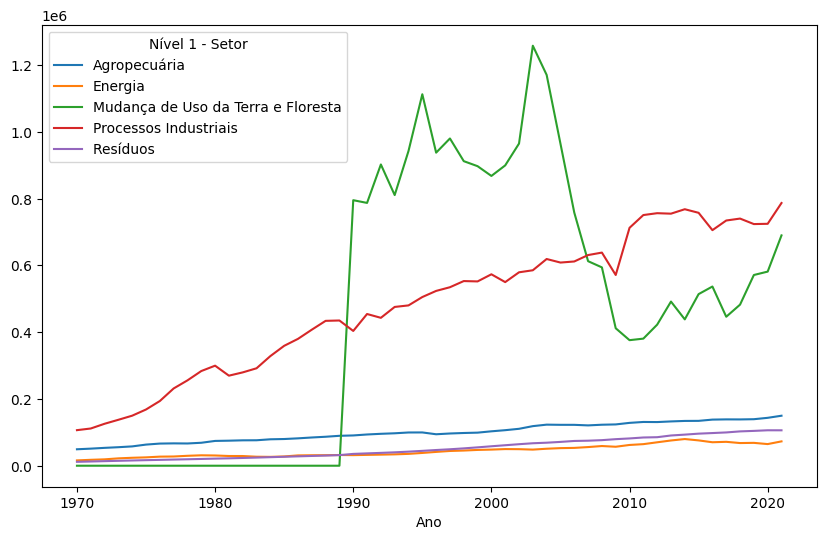

In [85]:
# Uma linha por setor (os setores são as colunas da tabela pivotada)
media_emissao_setor.plot(figsize=(10, 6));

### O que o gráfico revela

- **Mudança de Uso da Terra e Floresta** começa zerada (o SEEG só estima MUT a partir dos anos 1990), explode até o pico de **2003** — auge histórico do desmatamento na Amazônia — despenca até ~2012 (Código Florestal, fiscalização) e volta a subir forte a partir de 2019.
- **Processos Industriais** tem a maior média por linha em quase todo o período (poucas linhas, valores altos — a lição média × soma da Aula 02) e pico em **2021**.
- **Agropecuária** cresce quase monotônica — pico também em **2021**, o retrato da expansão contínua do rebanho e da soja.
- **Energia** oscila com a economia (pico em 2014) e **Resíduos** cresce devagar e constante, acompanhando população urbana.

Mesma base, três desafios (máximo do PA na Aula 01, ranking de setores na Aula 02, série temporal aqui) — e a história é sempre a mesma: as emissões do Brasil são uma questão de uso da terra.

## Desafio: hora da prática

Cinco itens sobre o agrupamento `Estado × Nível 1 - Setor` — o gêmeo do `gas_por_setor`, trocando `Gás` por `Estado`. Colchete duplo em `[['Emissão']]` para nascer DataFrame (o `insert`/`idxmax` da lição valem aqui também).

In [86]:
# 1) Soma de emissão por Estado × Setor
# Validação: (132, 1) — até 27 UFs × 5 setores (nem todo estado tem todos os setores)
emissao_estado_setor = emissoes_por_ano.groupby(['Estado', 'Nível 1 - Setor'])[['Emissão']].sum()

print(emissao_estado_setor.shape)
emissao_estado_setor

(132, 1)


Emissão
Estado Nível 1 - Setor                                 
AC     Agropecuária                        7.270206e+08
       Energia                             2.071751e+08
       Mudança de Uso da Terra e Floresta  7.847879e+09
       Resíduos                            2.928323e+07
AL     Agropecuária                        7.628303e+08
...                                                 ...
TO     Agropecuária                        2.762475e+09
       Energia                             5.130379e+08
       Mudança de Uso da Terra e Floresta  9.435591e+09
       Processos Industriais               2.613905e+07
       Resíduos                            6.177003e+07

[132 rows x 1 columns]

In [87]:
# 2) Só as linhas de Energia — xs fixa o nível INTERNO (level=1), coisa que loc simples não faz
emissao_estado_setor.xs('Energia', level=1)

,Emissão
Estado,
AC,2.071751e+08
AL,5.958697e+08
AM,1.916462e+09
AP,2.638059e+08
BA,4.801368e+09
CE,1.879584e+09
DF,9.487860e+08
ES,2.201326e+09
GO,2.761709e+09


In [88]:
# 3) O setor com maior emissão em Minas Gerais
# xs('MG') fatia o nível externo; idxmax devolve o rótulo do máximo, max devolve o valor
setor_max_mg = emissao_estado_setor.xs('MG', level=0).idxmax()
valor_max_mg = emissao_estado_setor.xs('MG', level=0).max()

print(f'MG: {setor_max_mg.iloc[0]} — {valor_max_mg.iloc[0]:.2e} t')

MG: Agropecuária — 1.45e+10 t


In [89]:
# 4) Setor campeão de emissão em CADA Estado
# groupby(level=0) agrupa pelo nível Estado; .str[1] extrai o setor da tupla do idxmax
setor_campeao_por_estado = emissao_estado_setor.groupby(level=0).idxmax()
setor_campeao_por_estado['Emissão'] = setor_campeao_por_estado['Emissão'].str[1]
setor_campeao_por_estado

,Emissão
Estado,
AC,Mudança de Uso da Terra e Floresta
AL,Agropecuária
AM,Mudança de Uso da Terra e Floresta
AP,Mudança de Uso da Terra e Floresta
BA,Mudança de Uso da Terra e Floresta
CE,Energia
DF,Energia
ES,Processos Industriais
GO,Agropecuária


In [90]:
# 5) Estado campeão de emissão em CADA setor — espelho do item 4
# groupby(level=1) agrupa pelo nível Setor; .str[0] extrai o Estado da tupla
estado_campeao_por_setor = emissao_estado_setor.groupby(level=1).idxmax()
estado_campeao_por_setor['Emissão'] = estado_campeao_por_setor['Emissão'].str[0]
estado_campeao_por_setor

,Emissão
Nível 1 - Setor,
Agropecuária,MG
Energia,SP
Mudança de Uso da Terra e Floresta,PA
Processos Industriais,MG
Resíduos,SP


### O que os números dizem

- **Item 3:** o setor campeão de MG é a **Agropecuária** (1,45 × 10¹⁰ t) — Minas tem o maior rebanho bovino do Sudeste, e o resultado bate com o item 5, onde MG aparece como o estado campeão da Agropecuária nacional.
- **Item 4:** dos 27 estados, **12 têm MUT como setor campeão** (Amazônia Legal quase inteira), 8 têm Energia (os industrializados e os do Nordeste), 6 Agropecuária e 1 Processos Industriais. O mapa das emissões é o mapa da economia de cada região.
- **Item 5:** os campeões nacionais — **PA** em MUT (desmatamento, o mesmo PA do desafio da Aula 01), **MG** em Agropecuária e Processos Industriais (rebanho + siderurgia), **SP** em Energia e Resíduos (maior frota e maior população urbana).

`level=0` × `level=1` no `groupby` respondem perguntas espelhadas sobre a mesma tabela: "qual setor domina cada estado" vs. "qual estado domina cada setor". Escolher o nível é escolher a pergunta.